In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("netflix_titles.csv")

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

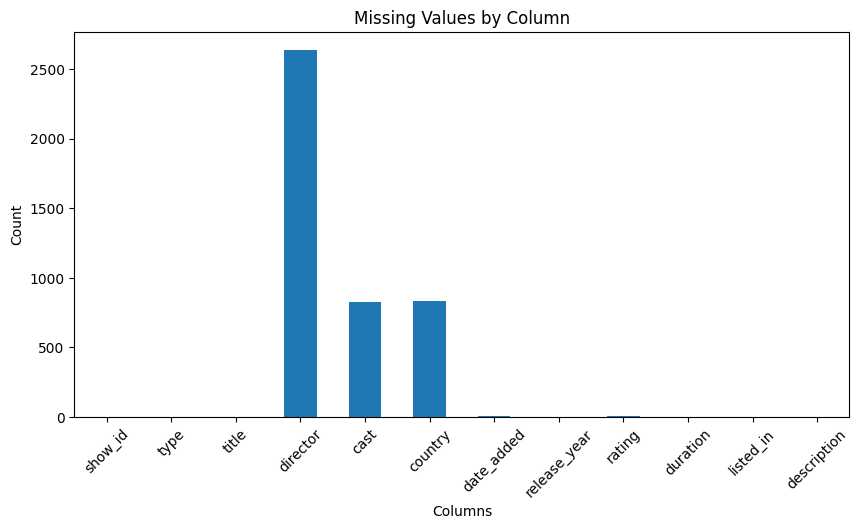

In [3]:
#Inspect the DataFrame with .info(), .describe(), and .head()
print(df.head()) 
print(df.info())

print(df.isnull().sum())
missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()
df = df.drop_duplicates()

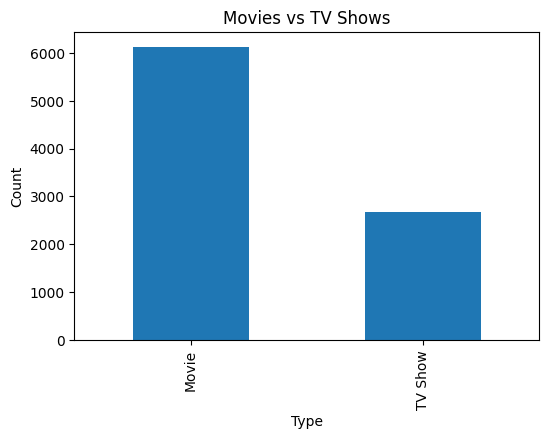

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [4]:

#Identify and handle missing values column by column
df["type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()
for col in df.columns:
    if  df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())


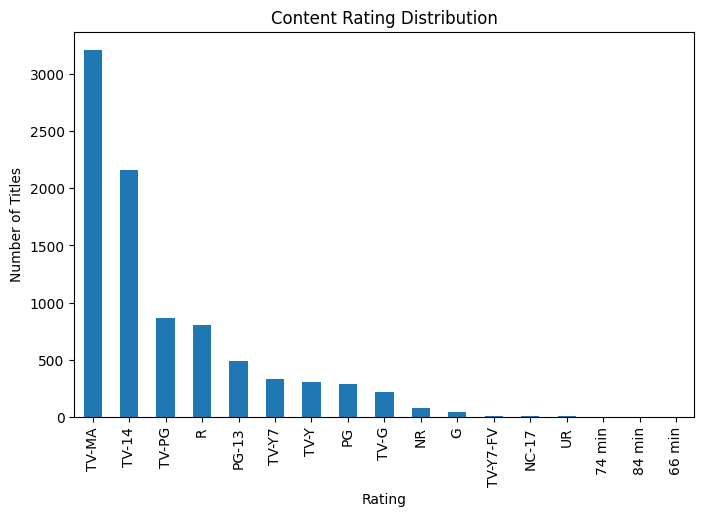

    duration  duration_value duration_unit
0     90 min            90.0           min
1  2 Seasons             2.0        Season
2   1 Season             1.0        Season
3   1 Season             1.0        Season
4  2 Seasons             2.0        Season


In [5]:
df["rating"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.show()
#Fix mixed-type columns (e.g., duration stored as "90 min")

df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"(min|Season|Seasons)")

print(df[["duration", "duration_value", "duration_unit"]].head())

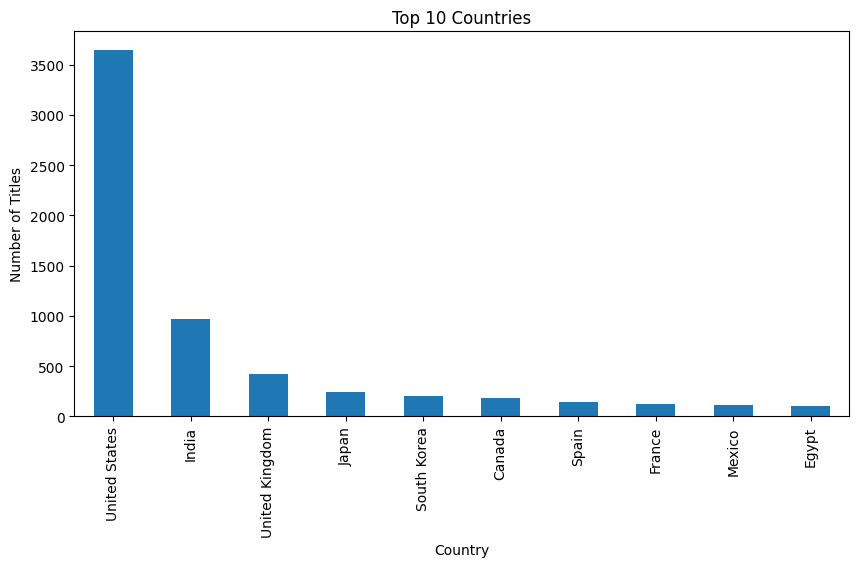

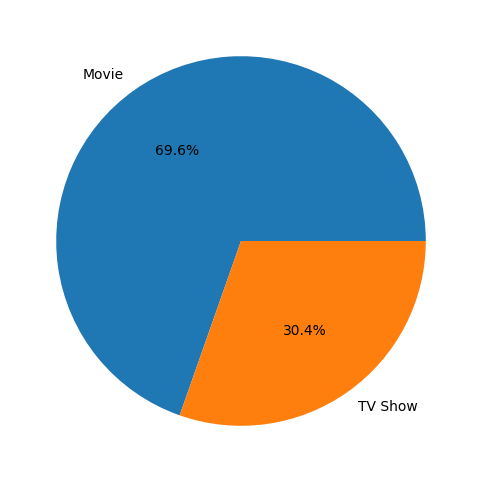

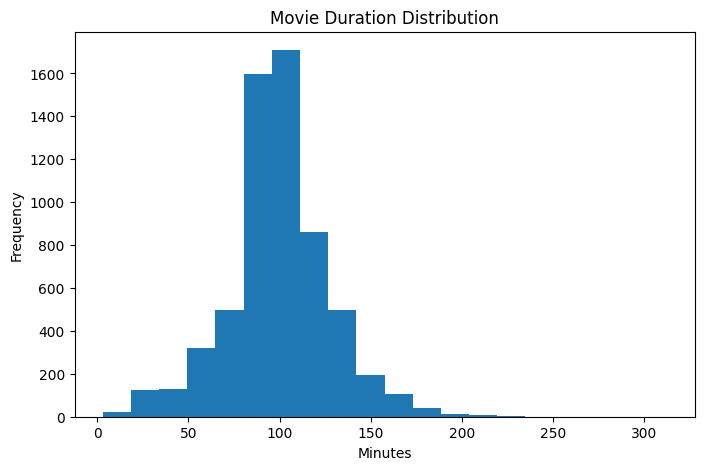

In [8]:
top_country = df["country"].value_counts().head(10)

top_country.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)


movies = df[df["duration_unit"] == "min"]

plt.figure(figsize=(8,5))

plt.hist(movies["duration_value"], bins=20)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

plt.show()

In [10]:
df.to_csv('cleaned_dataset.csv', index = False)
